In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('data/clean_data/output.csv')
df.head()

,tweet_id,lang,country,verified,sentiment_neutral,entail_prob,contra_prob,stance,region
0,1540451336876986373,cs,Slovakia,True,0.5044,0.30,0.70,unsure,Europe
1,1516696238212661253,ro,Italy,False,0.9146,0.18,0.82,unsure,Europe
2,1587766197298548738,te,India,True,0.5799,0.31,0.69,unsure,Asia
3,1586193152175529984,te,India,True,0.0000,0.03,0.97,unsure,Asia
4,1580452730212331520,te,India,True,0.0000,0.33,0.67,pro-Ukraine,Asia


In [3]:
B = nx.Graph()

stances = df["stance"].unique()
countries = df["country"].unique()

print(stances)
print(countries)

['unsure' 'pro-Ukraine' 'pro-Russia']
['Slovakia' 'Italy' 'India' 'Czech Republic' 'France' 'Ukraine' 'Nepal'
 'Japan' 'United States of America' 'Azerbaijan' 'South Africa'
 'South Korea' 'Latvia' 'Saudi Arabia' 'United Arab Emirates' 'Turkey'
 'Qatar' 'Israel' 'Egypt' 'Lebanon' 'State of Palestine'
 "People's Republic of China" 'Germany' 'Algeria' 'Morocco' 'Tunisia'
 'Iraq' 'United Kingdom' 'Syria' 'Iran' 'Libya' 'Bahrain' 'Kuwait'
 'Australia' 'Nigeria' 'Singapore' 'Pakistan' 'Canada' 'Malaysia'
 'Philippines' 'Afghanistan' 'Argentina' 'Portugal' 'Brazil' 'Chile'
 'Mexico' 'Spain' 'Bulgaria' 'Slovenia' 'Finland' 'Thailand' 'Denmark'
 'Norway' 'Tuvalu' 'Sweden' 'Lithuania' 'Romania' 'Bangladesh' 'Greece'
 'Cyprus' 'Russia' 'Kazakhstan' 'Belarus' 'Poland' 'Hungary' 'Switzerland'
 'Austria' 'Luxembourg' 'Republic of Ireland' 'Netherlands' 'Belgium'
 'Senegal' 'Indonesia' 'Haiti' 'Monaco' 'Cuba' 'Colombia' 'Venezuela'
 'Nicaragua' 'Guatemala' 'Peru' 'Honduras' 'Ecuador' 'Panama' 'Boliv

In [3]:
B.add_nodes_from(stances, bipartite='stance')
B.add_nodes_from(countries, bipartite='country')

for index, row in df.iterrows():
    B.add_edge(row['stance'], row['country'], tweet_id=row['tweet_id'], entail_prob=row["entail_prob"], contra_prob=row["contra_prob"])

In [4]:
stance_nodes = [node for node, attr in B.nodes(data=True) if attr['bipartite'] == 'stance']
country_nodes = [node for node, attr in B.nodes(data=True) if attr['bipartite'] == 'country']

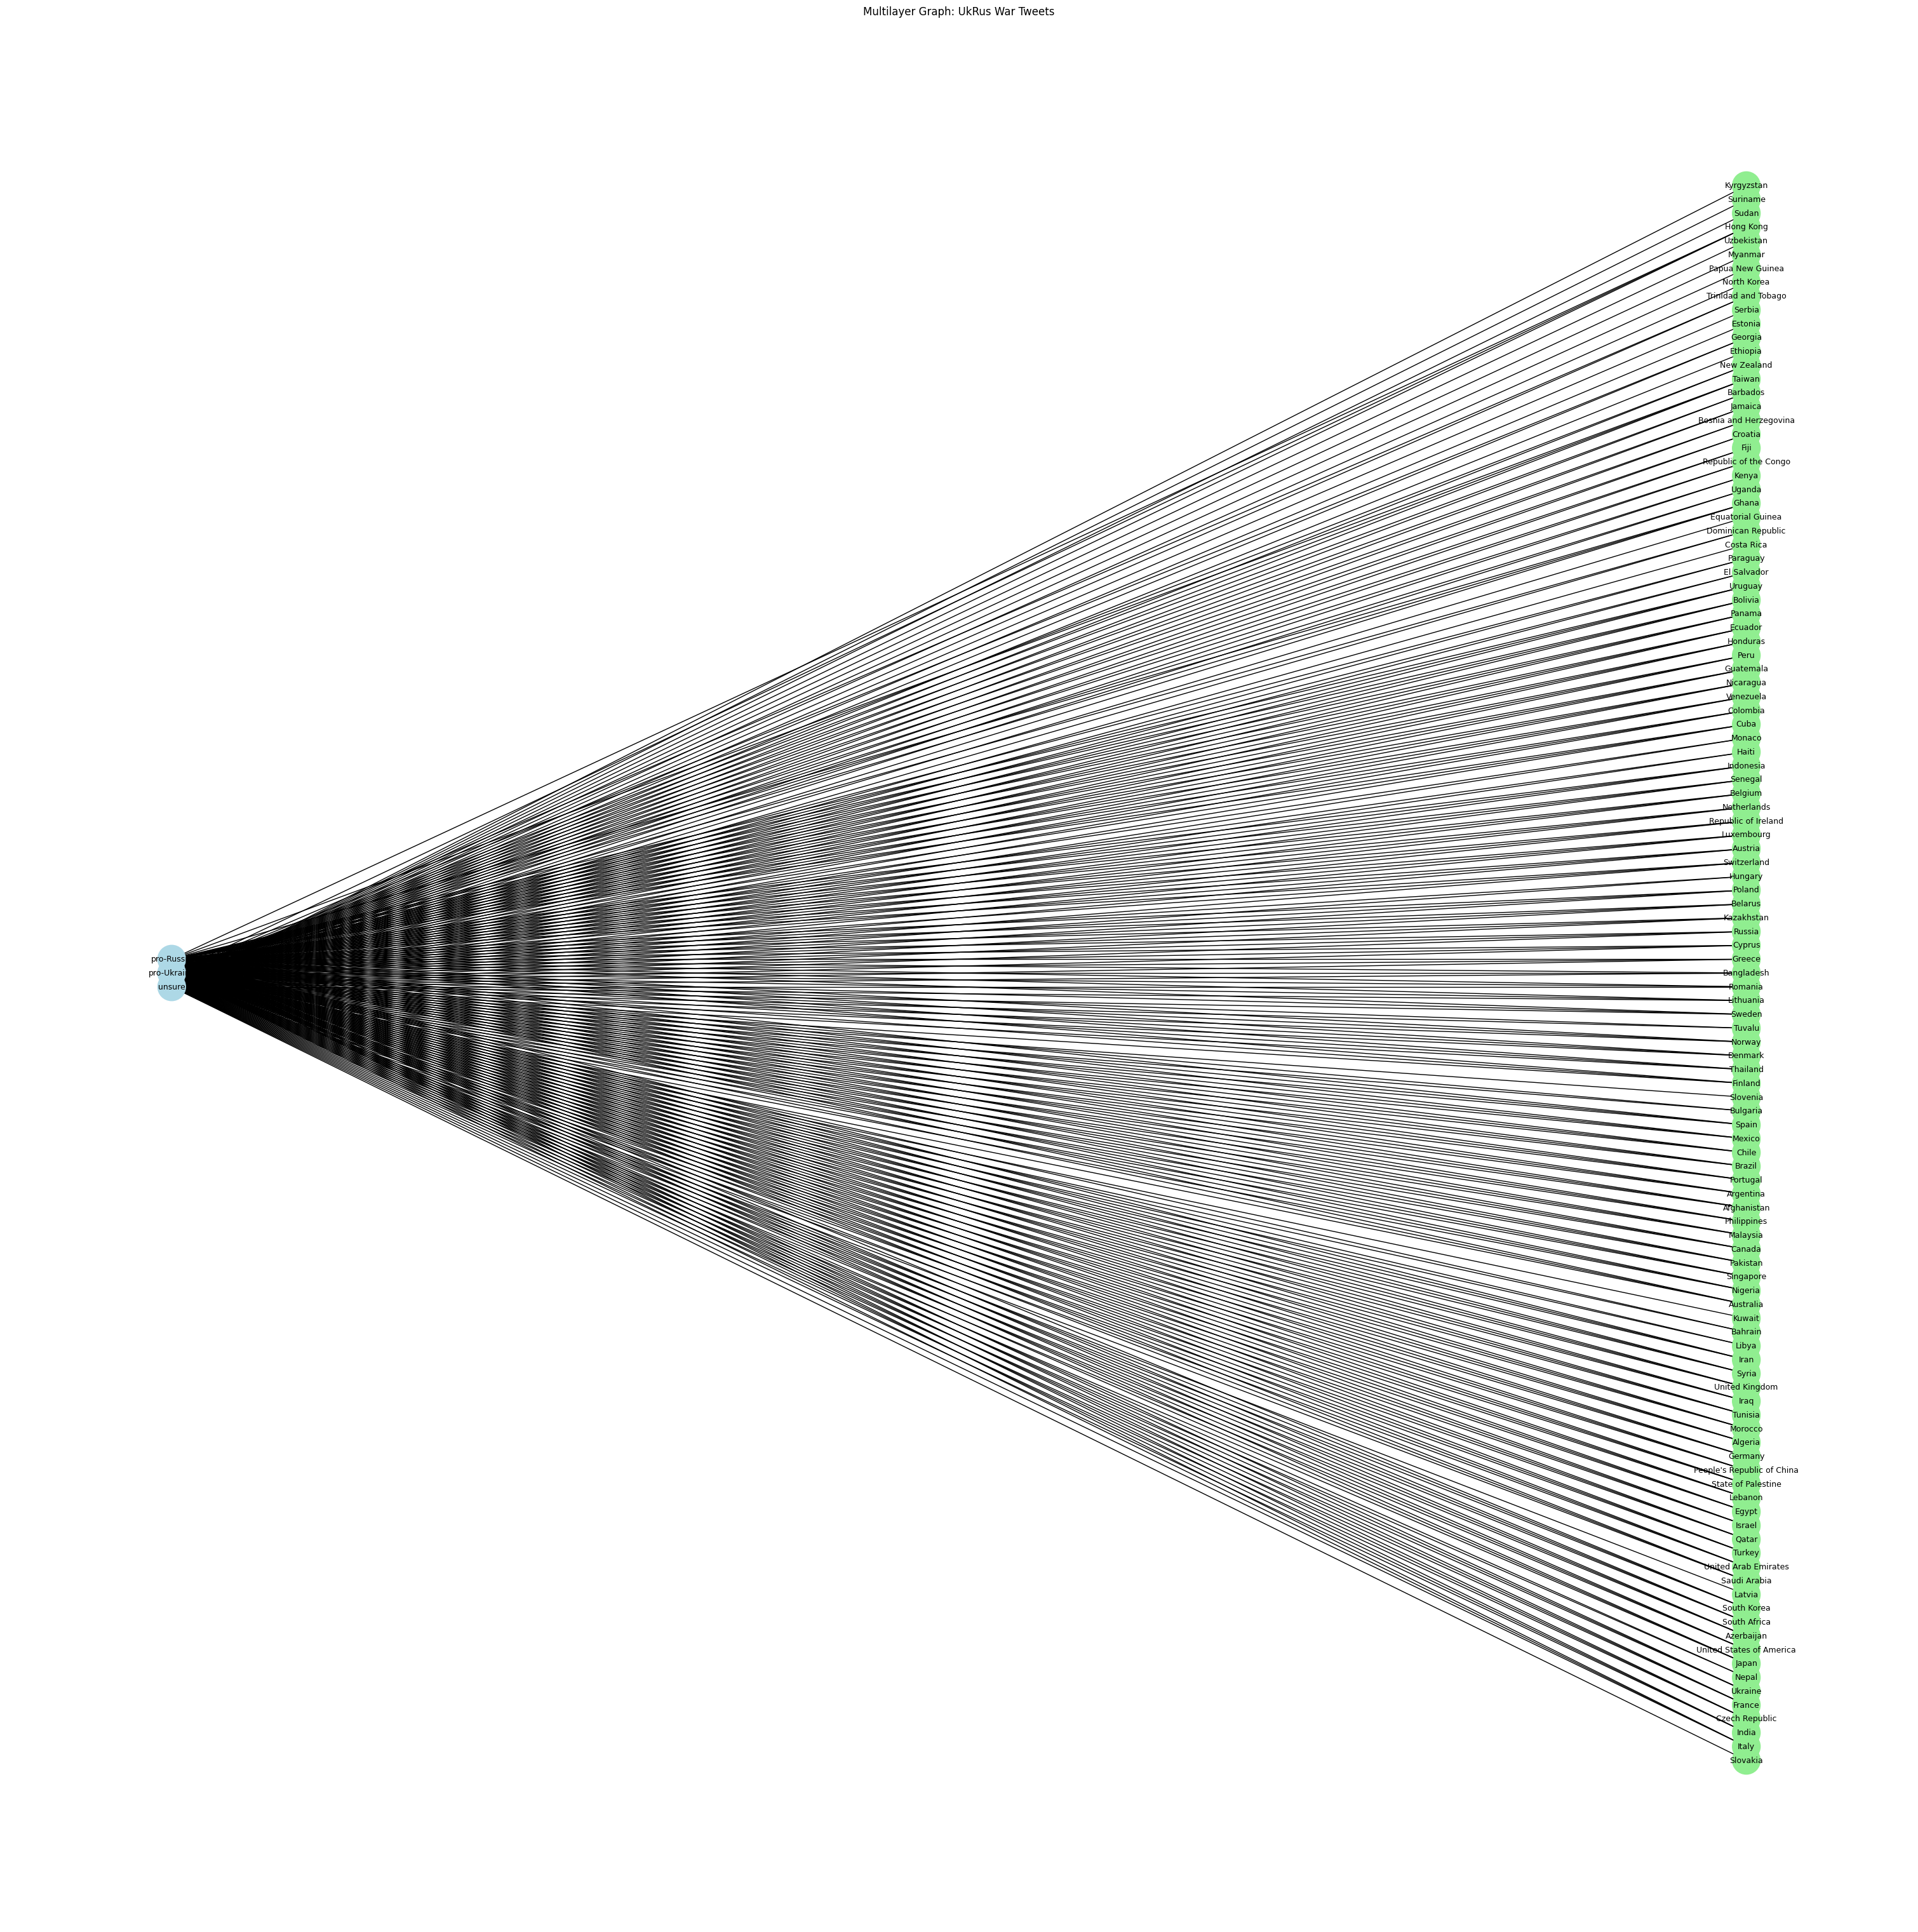

In [8]:
# Create position dictionary
pos = {}

# Position stances on the left
for i, node in enumerate(stance_nodes):
    pos[node] = (-1, i - len(stance_nodes)/2)

for i, node in enumerate(country_nodes):
    pos[node] = (0, i - len(country_nodes)/2)


# Add node colors by type
node_colors = []
for node in B.nodes():
    attr = B.nodes[node]['bipartite']
    if attr == 'stance':
        node_colors.append('lightblue')
    elif attr == 'country':
        node_colors.append('lightgreen')
    else:  # region
        node_colors.append('salmon')

plt.figure(figsize=(30, 30))
nx.draw(B, pos, with_labels=True, node_size=1000, font_size=9, node_color=node_colors)
plt.title("Multilayer Graph: UkRus War Tweets")
plt.savefig("data/Clean_Data/multilayer_graph.png")
plt.show()

# Use NetworkX's built-in community detection algorithms to compare with ML later

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Apply Louvain community detection using NetworkX
communities = nx.algorithms.community.louvain_communities(B)

# Convert communities to a partition dictionary
partition = {}
for i, community in enumerate(communities):
    for node in community:
        partition[node] = i

# Get number of communities
num_communities = len(communities)
print(f"Detected {num_communities} communities")

# Create a dictionary to store nodes in each community
communities_dict = {}
for i, community in enumerate(communities):
    communities_dict[i] = list(community)

# Print communities and their composition
for community_id, nodes in communities_dict.items():
    # Count node types in this community
    stance_count = sum(1 for node in nodes if B.nodes[node]['bipartite'] == 'stance')
    country_count = sum(1 for node in nodes if B.nodes[node]['bipartite'] == 'country')
    
    print(f"Community {community_id}: {len(nodes)} nodes ({stance_count} stances, {country_count} countries)")
    
    # Print the nodes in each category
    print("  Stances:", [node for node in nodes if B.nodes[node]['bipartite'] == 'stance'])
    print("  Countries:", [node for node in nodes if B.nodes[node]['bipartite'] == 'country'])
    print()



Detected 3 communities
Community 0: 41 nodes (1 stances, 40 countries)
  Stances: ['unsure']
  Countries: ['Bosnia and Herzegovina', 'India', 'Belgium', 'Canada', 'Equatorial Guinea', 'South Korea', 'Cuba', 'Uruguay', 'Switzerland', 'El Salvador', 'Kuwait', 'Bolivia', 'Bulgaria', 'Uzbekistan', 'Saudi Arabia', 'Kyrgyzstan', 'Latvia', 'North Korea', 'Honduras', 'Tuvalu', 'Slovenia', 'Suriname', 'Monaco', 'Ukraine', 'Austria', 'Turkey', 'Ethiopia', 'Costa Rica', 'France', 'Croatia', 'Slovakia', 'Myanmar', 'Serbia', 'Uganda', 'Peru', 'Georgia', 'Papua New Guinea', 'Hungary', 'Sudan', 'Estonia']

Community 1: 37 nodes (1 stances, 36 countries)
  Stances: ['pro-Ukraine']
  Countries: ['Finland', 'Lithuania', 'Nepal', 'Netherlands', 'Argentina', 'Chile', 'Australia', 'Morocco', 'Ecuador', 'South Africa', 'New Zealand', 'United States of America', 'Tunisia', 'Qatar', 'Dominican Republic', 'Colombia', 'Greece', 'Kenya', 'Afghanistan', 'Philippines', 'Jamaica', 'Libya', 'Haiti', 'Cyprus', 'Belar

In [17]:
import networkx.algorithms.community as nx_comm

# Girvan-Newman
communities_gn = nx_comm.girvan_newman(B)
# Take a specific level of the hierarchical partition
top_level_communities = next(communities_gn)
# Convert to list of sets
communities_gn_list = [list(c) for c in top_level_communities]

# Print communities
for i, community in enumerate(communities_gn_list):
    # Count node types
    stance_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'stance')
    country_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'country')
    
    print(f"GN Community {i}: {len(community)} nodes ({stance_count} stances, {country_count} countries)")
    print("  Stances:", [node for node in community if B.nodes[node]['bipartite'] == 'stance'])
    print("  Countries:", [node for node in community if B.nodes[node]['bipartite'] == 'country'])
    print()

GN Community 0: 117 nodes (3 stances, 114 countries)
  Stances: ['pro-Ukraine', 'unsure', 'pro-Russia']
  Countries: ['India', 'Cuba', 'Kuwait', 'Bolivia', 'Switzerland', 'Netherlands', 'Saudi Arabia', 'Latvia', 'Mexico', 'Honduras', 'Tuvalu', 'Slovenia', 'Croatia', 'Serbia', 'Afghanistan', 'Haiti', 'Uganda', 'Peru', 'Senegal', 'Russia', 'Syria', 'Luxembourg', 'Estonia', 'Bosnia and Herzegovina', 'Finland', 'South Korea', 'El Salvador', 'United Kingdom', 'Uzbekistan', 'Chile', 'Australia', 'Tunisia', 'Malaysia', 'Iraq', 'Ukraine', 'Costa Rica', 'France', 'Colombia', 'Republic of Ireland', 'Algeria', 'Fiji', 'Italy', 'Paraguay', 'Guatemala', 'Hong Kong', 'United Arab Emirates', 'Hungary', 'Kazakhstan', 'Nigeria', 'Belgium', 'Canada', 'Lithuania', 'Nepal', 'Singapore', 'Israel', 'Kyrgyzstan', 'Germany', 'North Korea', 'United States of America', 'Monaco', 'Japan', 'Brazil', 'Lebanon', 'Dominican Republic', 'Greece', 'Slovakia', 'Philippines', 'Jamaica', 'Bangladesh', 'Poland', 'Nicaragua

In [18]:
# Label Propagation
communities_lpa = nx_comm.label_propagation_communities(B)
communities_lpa_list = list(communities_lpa)

# Print communities
for i, community in enumerate(communities_lpa_list):
    # Count node types
    stance_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'stance')
    country_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'country')
    
    print(f"LPA Community {i}: {len(community)} nodes ({stance_count} stances, {country_count} countries)")
    print("  Stances:", [node for node in community if B.nodes[node]['bipartite'] == 'stance'])
    print("  Countries:", [node for node in community if B.nodes[node]['bipartite'] == 'country'])
    print()

LPA Community 0: 118 nodes (3 stances, 115 countries)
  Stances: ['pro-Ukraine', 'unsure', 'pro-Russia']
  Countries: ['India', 'Cuba', 'Kuwait', 'Bolivia', 'Switzerland', 'Netherlands', 'Saudi Arabia', 'Latvia', 'Mexico', 'Honduras', 'Tuvalu', 'Slovenia', 'Ethiopia', 'Croatia', 'Serbia', 'Afghanistan', 'Haiti', 'Uganda', 'Peru', 'Senegal', 'Russia', 'Syria', 'Luxembourg', 'Estonia', 'Bosnia and Herzegovina', 'Finland', 'South Korea', 'El Salvador', 'United Kingdom', 'Uzbekistan', 'Chile', 'Australia', 'Tunisia', 'Malaysia', 'Iraq', 'Ukraine', 'Costa Rica', 'France', 'Colombia', 'Republic of Ireland', 'Algeria', 'Fiji', 'Italy', 'Paraguay', 'Guatemala', 'Hong Kong', 'United Arab Emirates', 'Hungary', 'Kazakhstan', 'Nigeria', 'Belgium', 'Canada', 'Lithuania', 'Nepal', 'Singapore', 'Israel', 'Kyrgyzstan', 'Germany', 'North Korea', 'United States of America', 'Monaco', 'Japan', 'Brazil', 'Lebanon', 'Dominican Republic', 'Greece', 'Slovakia', 'Philippines', 'Jamaica', 'Bangladesh', 'Poland

In [19]:
# Greedy Modularity Maximization
communities_gmm = nx_comm.greedy_modularity_communities(B)
communities_gmm_list = list(communities_gmm)

# Print communities
for i, community in enumerate(communities_gmm_list):
    # Count node types
    stance_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'stance')
    country_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'country')
    
    print(f"GMM Community {i}: {len(community)} nodes ({stance_count} stances, {country_count} countries)")
    print("  Stances:", [node for node in community if B.nodes[node]['bipartite'] == 'stance'])
    print("  Countries:", [node for node in community if B.nodes[node]['bipartite'] == 'country'])
    print()

GMM Community 0: 40 nodes (1 stances, 39 countries)
  Stances: ['pro-Russia']
  Countries: ['Belgium', 'Canada', 'Uruguay', 'Cuba', 'Bolivia', 'Netherlands', "People's Republic of China", 'Egypt', 'Argentina', 'Saudi Arabia', 'Chile', 'Australia', 'Ecuador', 'South Africa', 'Tunisia', 'Malaysia', 'Norway', 'Czech Republic', 'Brazil', 'Austria', 'Lebanon', 'France', 'Colombia', 'Greece', 'Cyprus', 'Republic of Ireland', 'Afghanistan', 'Algeria', 'Iran', 'Poland', 'Belarus', 'Denmark', 'Bangladesh', 'Azerbaijan', 'Italy', 'State of Palestine', 'Hong Kong', 'United Arab Emirates', 'Syria']

GMM Community 1: 39 nodes (1 stances, 38 countries)
  Stances: ['unsure']
  Countries: ['India', 'Equatorial Guinea', 'Lithuania', 'South Korea', 'Kuwait', 'Sweden', 'United Kingdom', 'Uzbekistan', 'Kyrgyzstan', 'Latvia', 'Germany', 'North Korea', 'Mexico', 'Slovenia', 'Suriname', 'Japan', 'Iraq', 'Turkey', 'Ethiopia', 'Costa Rica', 'Slovakia', 'Myanmar', 'Serbia', 'Uganda', 'Peru', 'Nicaragua', 'Trini

In [27]:
# Fluid Communities (k is the number of communities)
k = 3 
communities_fluid = nx_comm.asyn_fluidc(B, k)
communities_fluid_list = list(communities_fluid)

# Print communities
for i, community in enumerate(communities_fluid_list):
    # Count node types
    stance_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'stance')
    country_count = sum(1 for node in community if B.nodes[node]['bipartite'] == 'country')
    
    print(f"Fluid Community {i}: {len(community)} nodes ({stance_count} stances, {country_count} countries)")
    print("  Stances:", [node for node in community if B.nodes[node]['bipartite'] == 'stance'])
    print("  Countries:", [node for node in community if B.nodes[node]['bipartite'] == 'country'])
    print()

Fluid Community 0: 39 nodes (1 stances, 38 countries)
  Stances: ['pro-Russia']
  Countries: ['India', 'Canada', 'Finland', 'Lithuania', 'South Korea', 'Argentina', 'Sweden', 'Egypt', 'United Kingdom', 'Saudi Arabia', 'Israel', 'Germany', 'South Africa', 'United States of America', 'Tunisia', 'Malaysia', 'Czech Republic', 'Iraq', 'Brazil', 'Austria', 'Qatar', 'Turkey', 'Ghana', 'France', 'Colombia', 'Cyprus', 'Afghanistan', 'Philippines', 'Algeria', 'Azerbaijan', 'Nicaragua', 'Peru', 'Poland', 'Senegal', 'State of Palestine', 'United Arab Emirates', 'Thailand', 'Kazakhstan']

Fluid Community 1: 39 nodes (1 stances, 38 countries)
  Stances: ['pro-Ukraine']
  Countries: ['Belgium', 'Bolivia', 'Cuba', 'Bulgaria', 'Chile', 'Australia', 'Morocco', 'Ecuador', 'Honduras', 'New Zealand', 'Tuvalu', 'Norway', 'Monaco', 'Japan', 'Indonesia', 'Croatia', 'Greece', 'Libya', 'Republic of Ireland', 'Jamaica', 'Uganda', 'Haiti', 'Belarus', 'Denmark', 'Trinidad and Tobago', 'Romania', 'Fiji', 'Italy', '

In [23]:
# Run the algorithms and store results
community_algorithms = {
    "Louvain": list(nx_comm.louvain_communities(B)),
    "Label Propagation": list(nx_comm.label_propagation_communities(B)),
    "Greedy Modularity": list(nx_comm.greedy_modularity_communities(B)),
    "Fluid Communities": list(nx_comm.asyn_fluidc(B, 3))
}

# Calculate modularity for each algorithm's result
for algo_name, communities in community_algorithms.items():
    # Convert communities to partition dict for modularity calculation
    partition = {}
    for i, community in enumerate(communities):
        for node in community:
            partition[node] = i
            
    modularity = nx_comm.modularity(B, communities)
    print(f"{algo_name}: {len(communities)} communities, modularity = {modularity:.4f}")

Louvain: 3 communities, modularity = 0.0619
Label Propagation: 1 communities, modularity = 0.0000
Greedy Modularity: 3 communities, modularity = 0.0619
Fluid Communities: 3 communities, modularity = 0.0306


In [24]:
# Project the bipartite graph onto one node set
country_graph = nx.bipartite.projected_graph(B, country_nodes)

# Run community detection on the projected graph
communities_projected = nx_comm.louvain_communities(country_graph)
communities_projected_list = list(communities_projected)

# Print communities
for i, community in enumerate(communities_projected_list):
    print(f"Projected Community {i}: {len(community)} countries")
    print("  Countries:", list(community))
    print()

Projected Community 0: 115 countries
  Countries: ['India', 'Canada', 'Belgium', 'Lithuania', 'Cuba', 'Kuwait', 'Bolivia', 'Nepal', 'Singapore', 'Netherlands', 'Switzerland', 'Saudi Arabia', 'Kyrgyzstan', 'Israel', 'Latvia', 'Germany', 'North Korea', 'Mexico', 'Honduras', 'United States of America', 'Tuvalu', 'Slovenia', 'Monaco', 'Japan', 'Brazil', 'Lebanon', 'Ethiopia', 'Croatia', 'Dominican Republic', 'Greece', 'Slovakia', 'Serbia', 'Afghanistan', 'Haiti', 'Jamaica', 'Philippines', 'Uganda', 'Nigeria', 'Poland', 'Peru', 'Bangladesh', 'Nicaragua', 'Senegal', 'Russia', 'Georgia', 'Spain', 'Taiwan', 'Syria', 'Luxembourg', 'Papua New Guinea', 'Pakistan', 'Thailand', 'Sudan', 'Republic of the Congo', 'Estonia', 'Bosnia and Herzegovina', 'Finland', 'Equatorial Guinea', 'Uruguay', 'South Korea', 'El Salvador', 'Bulgaria', 'Egypt', 'Sweden', 'Argentina', "People's Republic of China", 'United Kingdom', 'Uzbekistan', 'Chile', 'Australia', 'Morocco', 'Ecuador', 'Panama', 'South Africa', 'New Z

# Machine Learning

In [8]:
ml_graph = nx.Graph()
ml_graph.add_nodes_from(stances, bipartite='stance')
ml_graph.add_nodes_from(countries, bipartite='country')

# Dictionary to store all data for each edge
edge_data = {}

for index, row in df.iterrows():
    stance = row['stance']
    country = row['country']
    
    # Create edge key (normalize order for undirected graph)
    edge_key = tuple(sorted([stance, country]))
    
    # Initialize edge data if not exists
    if edge_key not in edge_data:
        edge_data[edge_key] = {
            'count': 0,
            'tweet_ids': [],
            'entail_probs': [],
            'contra_probs': []
        }
    
    # Update edge data
    edge_data[edge_key]['count'] += 1
    edge_data[edge_key]['tweet_ids'].append(row['tweet_id'])
    edge_data[edge_key]['entail_probs'].append(row['entail_prob'])
    edge_data[edge_key]['contra_probs'].append(row['contra_prob'])

In [10]:
import numpy as np

for edge_key, data in edge_data.items():
    node1, node2 = edge_key
    
    # Add edge with weight and aggregated attributes
    ml_graph.add_edge(
        node1, 
        node2,
        weight=data['count'],  # Number of duplicate edges
        tweet_ids=data['tweet_ids'],  # List of all tweet IDs
        avg_entail_prob=sum(data['entail_probs']) / data['count'],
        avg_contra_prob=sum(data['contra_probs']) / data['count'],
        entail_std=np.std(data['entail_probs']) if data['count'] > 1 else 0,
        contra_std=np.std(data['contra_probs']) if data['count'] > 1 else 0,
        entail_min=min(data['entail_probs']),
        entail_max=max(data['entail_probs']),
        contra_min=min(data['contra_probs']),
        contra_max=max(data['contra_probs'])
    )

# Verify the graph
print(f"Number of nodes: {ml_graph.number_of_nodes()}")
print(f"Number of edges: {ml_graph.number_of_edges()}")

Number of nodes: 118
Number of edges: 291


In [11]:
# Check edge weights
edge_weights = nx.get_edge_attributes(ml_graph, 'weight')
print(f"Max edge weight: {max(edge_weights.values())}")
print(f"Min edge weight: {min(edge_weights.values())}")
print(f"Average edge weight: {sum(edge_weights.values()) / len(edge_weights)}")

sorted_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 edges by weight:")
for (edge, weight) in sorted_edges[:5]:
    print(f"{edge}: {weight}")

Max edge weight: 60809
Min edge weight: 1
Average edge weight: 2221.9003436426115

Top 5 edges by weight:
('unsure', 'Turkey'): 60809
('unsure', 'Saudi Arabia'): 56600
('unsure', 'United States of America'): 51475
('unsure', 'Ukraine'): 49608
('unsure', 'Israel'): 25057


In [12]:
import numpy as np
import pandas as pd
from node2vec import Node2Vec
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Generate node2vec embeddings
# Configure node2vec parameters
node2vec_model = Node2Vec(
    ml_graph, 
    dimensions=64,        # Embedding dimension
    walk_length=30,       # Length of random walks
    num_walks=200,        # Number of walks per node
    workers=4,            # Number of parallel workers
    p=1,                  # Return parameter
    q=1,                  # In-out parameter
    weight_key='weight'   # Use edge weights
)

Computing transition probabilities:   0%|          | 0/118 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 102.91it/s]


In [14]:
# Fit the node2vec model
print("Generating node2vec embeddings...")
model = node2vec_model.fit(
    window=10,
    min_count=1,
    batch_words=4
)

# Extract embeddings for all nodes
embeddings = {}
embedding_matrix = []
node_list = []

for node in ml_graph.nodes():
    embeddings[node] = model.wv[node]
    embedding_matrix.append(model.wv[node])
    node_list.append(node)

embedding_matrix = np.array(embedding_matrix)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Generating node2vec embeddings...
Embedding matrix shape: (118, 64)


Finding optimal number of clusters...


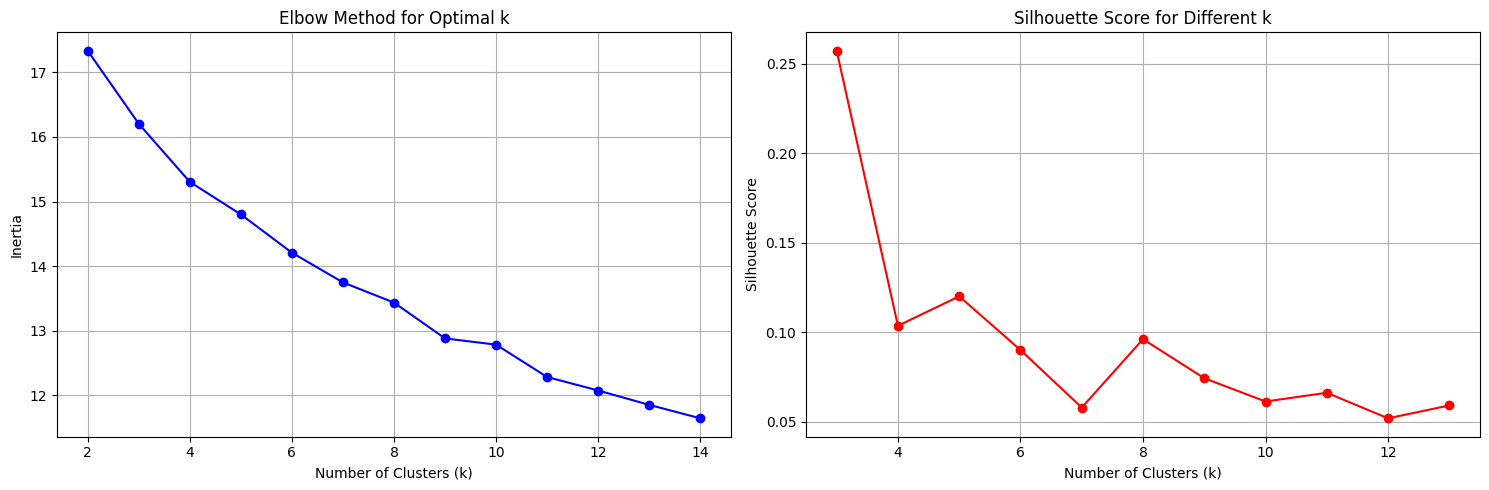

Optimal number of clusters: 2


In [16]:
inertias = []
silhouette_scores = []
K_range = range(2, min(15, len(ml_graph.nodes()) // 2))

print("Finding optimal number of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embedding_matrix)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score (skip if k is too small/large)
    if k > 1 and k < len(ml_graph.nodes()) - 1:
        score = silhouette_score(embedding_matrix, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow method
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette scores
ax2.plot(list(K_range)[1:-1], silhouette_scores[1:-1], 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

**Run K-Means with the optimal number of clusters**

In [17]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embedding_matrix)

# Create results dictionary
clustering_results = dict(zip(node_list, cluster_labels))

In [18]:
cluster_analysis = {}
for cluster_id in range(optimal_k):
    cluster_nodes = [node for node, label in clustering_results.items() if label == cluster_id]
    
    stances = [n for n in cluster_nodes if ml_graph.nodes[n].get('bipartite') == 'stance']
    countries = [n for n in cluster_nodes if ml_graph.nodes[n].get('bipartite') == 'country']
    
    # Calculate cluster statistics
    cluster_subgraph = ml_graph.subgraph(cluster_nodes)
    
    cluster_analysis[cluster_id] = {
        'nodes': cluster_nodes,
        'stances': stances,
        'countries': countries,
        'size': len(cluster_nodes),
        'edges': cluster_subgraph.number_of_edges(),
        'density': nx.density(cluster_subgraph) if len(cluster_nodes) > 1 else 0,
        'avg_degree': np.mean([ml_graph.degree(n) for n in cluster_nodes]),
        'avg_weight': np.mean([d['weight'] for u, v, d in cluster_subgraph.edges(data=True)]) if cluster_subgraph.number_of_edges() > 0 else 0
    }

# Print cluster analysis
for cluster_id, analysis in cluster_analysis.items():
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {analysis['size']} nodes")
    print(f"  Stances: {analysis['stances']}")
    print(f"  Countries: {analysis['countries']}")
    print(f"  Density: {analysis['density']:.3f}")
    print(f"  Average degree: {analysis['avg_degree']:.2f}")
    print(f"  Average edge weight: {analysis['avg_weight']:.2f}")


Cluster 0:
  Size: 59 nodes
  Stances: ['unsure', 'pro-Ukraine', 'pro-Russia']
  Countries: ['Italy', 'India', 'Czech Republic', 'France', 'Ukraine', 'Japan', 'United States of America', 'Saudi Arabia', 'United Arab Emirates', 'Turkey', 'Qatar', 'Israel', 'Egypt', 'Lebanon', 'State of Palestine', "People's Republic of China", 'Germany', 'Algeria', 'Morocco', 'Iraq', 'United Kingdom', 'Syria', 'Iran', 'Australia', 'Nigeria', 'Singapore', 'Pakistan', 'Canada', 'Malaysia', 'Philippines', 'Argentina', 'Portugal', 'Brazil', 'Chile', 'Mexico', 'Spain', 'Finland', 'Thailand', 'Denmark', 'Norway', 'Sweden', 'Romania', 'Bangladesh', 'Greece', 'Cyprus', 'Russia', 'Belarus', 'Poland', 'Switzerland', 'Republic of Ireland', 'Netherlands', 'Belgium', 'Indonesia', 'Colombia', 'Venezuela', 'Panama']
  Density: 0.098
  Average degree: 7.78
  Average edge weight: 3809.99

Cluster 1:
  Size: 59 nodes
  Stances: []
  Countries: ['Slovakia', 'Nepal', 'Azerbaijan', 'South Africa', 'South Korea', 'Latvia', 

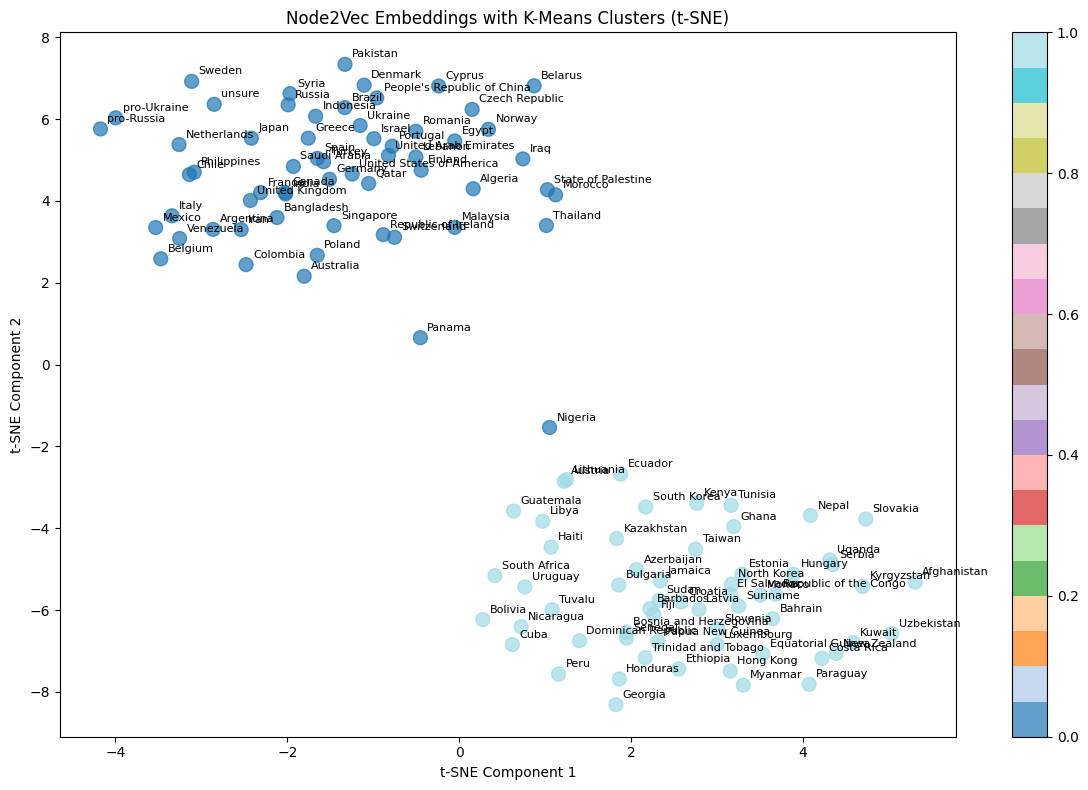

In [19]:
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embedding_matrix)//4))
embeddings_2d = tsne.fit_transform(embedding_matrix)

# Create visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     c=cluster_labels, cmap='tab20', s=100, alpha=0.7)

# Add labels
for i, node in enumerate(node_list):
    plt.annotate(node, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.colorbar(scatter)
plt.title('Node2Vec Embeddings with K-Means Clusters (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering

# Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(embedding_matrix)

# Spectral clustering
spectral = SpectralClustering(n_clusters=optimal_k, random_state=42)
spectral_labels = spectral.fit_predict(embedding_matrix)

# Compare different clustering methods
clustering_methods = {
    'K-Means': cluster_labels,
    'Hierarchical': hierarchical_labels,
    'Spectral': spectral_labels
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'node': node_list,
    'type': [ml_graph.nodes[n].get('bipartite') for n in node_list],
    **clustering_methods
})

# Save results
comparison_df.to_csv('node2vec_clustering_results.csv', index=False)

In [24]:
# 6. Evaluate clustering quality
print("\nClustering Quality Metrics:")
for method_name, labels in clustering_methods.items():
    if -1 not in labels:
        score = silhouette_score(embedding_matrix, labels)
        print(f"{method_name}: Silhouette Score = {score:.3f}")
    else:
        mask = labels != -1
        if np.sum(mask) > 1:
            score = silhouette_score(embedding_matrix[mask], labels[mask])
            print(f"{method_name}: Silhouette Score = {score:.3f} (excluding noise)")


Clustering Quality Metrics:
K-Means: Silhouette Score = 0.369
Hierarchical: Silhouette Score = 0.364
Spectral: Silhouette Score = 0.369
